# AI in Digital Pathology - Video 4
## ABMIL: Attention-Based Multiple Instance Learning
### BR2082c TMA · Phikon-v2 · PyTorch

**What this notebook covers:**

In Video 3 we classified TMA cores using mean pooling - all tile embeddings averaged equally into one core vector. We achieved 91% accuracy but DCIS F1 was only 0.57, because mean pooling dilutes the informative tiles with uninformative ones.

This video replaces mean pooling with **attention pooling**. The model learns a weight for each tile based on how relevant it is to the classification. Those weights are the attention heatmap.

**The Multiple Instance Learning (MIL) framing:**
- A **bag** = one TMA core = a collection of tile embeddings
- An **instance** = one tile embedding (1024-dim vector from Phikon-v2)
- A **bag label** = the core diagnosis (Carcinoma / DCIS / Normal/Benign)
- MIL problem: predict the bag label from its instances, with no instance-level labels

**Key architectural difference from Video 3:**

| Video 3 | Video 4 |
|---|---|
| mean(h1, h2, ..., hN) | sum(a1*h1, a2*h2, ..., aN*hN) |
| all tiles equal weight | attention network learns tile weights |
| sklearn logistic regression | custom PyTorch ABMIL |
| no spatial interpretation | attention heatmap as by-product |

**This notebook is fully self-contained.** It loads images from disk, extracts embeddings, trains, and evaluates without depending on any Video 3 outputs.

**Reference:** Ilse et al. (2018) Attention-based Deep Multiple Instance Learning. ICML.

## Cell 1: Imports and environment check

In [1]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
from PIL import Image
from transformers import AutoImageProcessor, AutoModel
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from tqdm import tqdm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Device: cuda
GPU: NVIDIA RTX 4000 Ada Generation
VRAM: 21.5 GB


## Cell 2: Paths

Adjust `PROJECT_ROOT` if needed. Same directory structure as Video 3 but results go to `results/video4/`.

In [2]:
PROJECT_ROOT = r"C:\Users\m6sbhatt\Documents\Personal\python_projects\AI_in_Digital_Pathology"

TMA_DIR    = os.path.join(PROJECT_ROOT, "images", "P1522Q0001-0008")
CORE_DIR   = os.path.join(TMA_DIR, "core_images")
EXCEL_PATH = os.path.join(TMA_DIR, "BR2082c specs.xlsx")
OUTPUT_DIR = os.path.join(PROJECT_ROOT, "results", "video4")
os.makedirs(OUTPUT_DIR, exist_ok=True)

FNAME_PREFIX = "P1522Q0001-0008-1522-H&E-(06.07.19)_"

print(f"Core dir:  {CORE_DIR}")
print(f"Excel:     {EXCEL_PATH}")
print(f"Output:    {OUTPUT_DIR}")

Core dir:  C:\Users\m6sbhatt\Documents\Personal\python_projects\AI_in_Digital_Pathology\images\P1522Q0001-0008\core_images
Excel:     C:\Users\m6sbhatt\Documents\Personal\python_projects\AI_in_Digital_Pathology\images\P1522Q0001-0008\BR2082c specs.xlsx
Output:    C:\Users\m6sbhatt\Documents\Personal\python_projects\AI_in_Digital_Pathology\results\video4


## Cell 3: Load labels from Excel

Identical label loading to Video 3. Three classes: Carcinoma (0), DCIS (1), Normal/Benign (2).

In [3]:
CLASS_NAMES  = ['Carcinoma', 'DCIS', 'Normal/Benign']
CLASS_COLORS = ['#DC2626', '#0D9488', '#1B2A4A']

def assign_class(diagnosis):
    if not isinstance(diagnosis, str):
        return None
    d = diagnosis.lower()
    if 'metastatic' in d or 'invasive carcinoma of no special type' in d:
        return 0
    if 'ductal carcinoma in situ' in d or 'intraductal' in d:
        return 1
    if any(x in d for x in ['fibroadenoma', 'hyperplasia', 'adjacent normal',
                              'cancer adjacent', 'breast tissue', 'adenosis',
                              'mastitis', 'papillomatosis']):
        return 2
    return None

df_raw = pd.read_excel(EXCEL_PATH, skiprows=5, header=0)
df_raw.columns = [
    'Position', 'No', 'Age', 'Sex', 'Organ', 'Diagnosis',
    'TNM', 'Grade', 'Stage', 'Type', 'TissueID',
    'ER', 'PR', 'HER2', 'Ki67'
]
df_raw = df_raw.dropna(subset=['Position'])
df_raw['Position'] = df_raw['Position'].astype(str).str.strip()
df_raw['ClassID']  = df_raw['Diagnosis'].apply(assign_class)

df = df_raw[df_raw['ClassID'].notna()].copy()
df['ClassID']   = df['ClassID'].astype(int)
df['ImagePath'] = df['Position'].apply(
    lambda pos: os.path.join(CORE_DIR, f"{FNAME_PREFIX}{pos}.png")
)
df['FileExists'] = df['ImagePath'].apply(os.path.exists)
df = df[df['FileExists']].copy()

print(f"Cores available: {len(df)}")
for cls_id, cls_name in enumerate(CLASS_NAMES):
    print(f"  {cls_name}: {(df['ClassID'] == cls_id).sum()}")

Cores available: 162
  Carcinoma: 97
  DCIS: 18
  Normal/Benign: 47


## Cell 4: Tiling and Phikon-v2 embedding functions

Same tiling and background filtering as Video 3:
- Tile size: 256x256, stride 256 (non-overlapping)
- Keep tile if: mean <= 243 OR std >= 4
- Background has mean ~245.7, std ~0.4 - cleanly excluded

Key difference from Video 3: `tile_and_embed_core()` now returns the **full matrix** of tile embeddings `(N_tiles, 1024)` plus their coordinates. In Video 3 we immediately took the mean. Here we keep every tile embedding separately - this is the bag of instances that ABMIL needs.

We load Phikon-v2 here too.

In [4]:
TILE_SIZE  = 256
STRIDE     = 256
BG_MEAN    = 243
BG_STD     = 4
BATCH_SIZE = 32

print("Loading Phikon-v2 ...")
processor = AutoImageProcessor.from_pretrained("owkin/phikon-v2")
phikon    = AutoModel.from_pretrained("owkin/phikon-v2")
phikon    = phikon.to(device)
phikon.eval()
print(f"Model loaded on: {device}")


def tile_core(img_np):
    """Return non-background tiles and (row, col) coords."""
    H, W = img_np.shape[:2]
    tiles, coords = [], []
    for r in range(0, H - TILE_SIZE + 1, STRIDE):
        for c in range(0, W - TILE_SIZE + 1, STRIDE):
            tile = img_np[r:r + TILE_SIZE, c:c + TILE_SIZE]
            if tile.mean() <= BG_MEAN or tile.std() >= BG_STD:
                tiles.append(tile)
                coords.append((r, c))
    if not tiles:
        return np.array([]).reshape(0, TILE_SIZE, TILE_SIZE, 3), []
    return np.array(tiles), coords


def embed_tiles(tiles):
    """Embed a batch of tiles. Returns (N, 1024)."""
    all_emb = []
    n_batches = int(np.ceil(len(tiles) / BATCH_SIZE))
    for i in range(n_batches):
        batch     = tiles[i * BATCH_SIZE : (i + 1) * BATCH_SIZE]
        pil_batch = [Image.fromarray(t) for t in batch]
        inputs    = processor(images=pil_batch, return_tensors="pt").to(device)
        with torch.no_grad():
            out = phikon(**inputs)
        all_emb.append(out.last_hidden_state[:, 0, :].cpu().numpy())
    return np.vstack(all_emb)


def tile_and_embed_core(img_path):
    """Load core, tile, embed. Returns (N_tiles, 1024) matrix and coords."""
    img_np        = np.array(Image.open(img_path).convert('RGB'))
    tiles, coords = tile_core(img_np)
    if len(tiles) == 0:
        return None, []
    embs = embed_tiles(tiles)
    return embs, coords


# Quick test on one core
test_embs, test_coords = tile_and_embed_core(df.iloc[0]['ImagePath'])
print(f"Test core {df.iloc[0]['Position']}: {test_embs.shape} embeddings")

Loading Phikon-v2 ...


Loading weights:   0%|          | 0/439 [00:00<?, ?it/s]

Model loaded on: cuda
Test core A1: (79, 1024) embeddings


## Cell 5: Extract per-tile embeddings for all cores

We extract and store the full `(N_tiles, 1024)` matrix for every core. This is what ABMIL receives as input - a bag of tile embeddings.

Unlike Video 3, we do **not** mean-pool here. The bags have variable size (different number of non-background tiles per core) which is fine - ABMIL handles variable-length bags naturally.

**Time estimate:** same as Video 3 - roughly 4 minutes on the RTX 4000 Ada.

We store bags as a Python list of numpy arrays (since bags have different sizes we cannot stack them into a single array).

In [5]:
bags      = []   # list of (N_i, 1024) arrays - one per core
bag_labels = []  # list of int class labels
bag_positions = [] # list of position strings for tracking
bag_coords  = []   # list of coord lists for spatial reconstruction
skipped     = []

print(f"Extracting per-tile embeddings for {len(df)} cores ...")

for _, row in tqdm(df.iterrows(), total=len(df), desc="Cores"):
    embs, coords = tile_and_embed_core(row['ImagePath'])
    if embs is None:
        skipped.append(row['Position'])
        continue
    bags.append(embs)
    bag_labels.append(row['ClassID'])
    bag_positions.append(row['Position'])
    bag_coords.append(coords)

bag_labels = np.array(bag_labels)

if skipped:
    print(f"Skipped (empty): {skipped}")

print(f"\nTotal bags: {len(bags)}")
print(f"Bag sizes - min: {min(len(b) for b in bags)}, "
      f"max: {max(len(b) for b in bags)}, "
      f"mean: {np.mean([len(b) for b in bags]):.1f}")
print("Class distribution:")
for cls_id, cls_name in enumerate(CLASS_NAMES):
    print(f"  {cls_name}: {(bag_labels == cls_id).sum()}")

Extracting per-tile embeddings for 162 cores ...


Cores: 100%|██████████| 162/162 [04:02<00:00,  1.50s/it]


Total bags: 162
Bag sizes - min: 31, max: 106, mean: 87.4
Class distribution:
  Carcinoma: 97
  DCIS: 18
  Normal/Benign: 47


## Cell 6: Train/test split

Stratified 80/20 split, seed 42 - identical to Video 3 so we are comparing on the same test cores.

In [6]:
indices = np.arange(len(bags))

train_idx, test_idx = train_test_split(
    indices,
    test_size=0.2,
    stratify=bag_labels,
    random_state=42
)

train_bags   = [bags[i] for i in train_idx]
test_bags    = [bags[i] for i in test_idx]
train_labels = bag_labels[train_idx]
test_labels  = bag_labels[test_idx]
test_positions = [bag_positions[i] for i in test_idx]
test_coords_list = [bag_coords[i] for i in test_idx]

print(f"Train: {len(train_bags)} bags")
print(f"Test:  {len(test_bags)} bags")
print("\nTrain class distribution:")
for cls_id, cls_name in enumerate(CLASS_NAMES):
    print(f"  {cls_name}: {(train_labels == cls_id).sum()}")
print("\nTest class distribution:")
for cls_id, cls_name in enumerate(CLASS_NAMES):
    print(f"  {cls_name}: {(test_labels == cls_id).sum()}")

Train: 129 bags
Test:  33 bags

Train class distribution:
  Carcinoma: 77
  DCIS: 14
  Normal/Benign: 38

Test class distribution:
  Carcinoma: 20
  DCIS: 4
  Normal/Benign: 9


## Cell 7: MIL Dataset

A minimal PyTorch Dataset that wraps our list of bags. Each item is a tuple of `(bag_tensor, label)` where `bag_tensor` has shape `(N_tiles, 1024)` and N_tiles varies per core.

We use `batch_size=1` in the DataLoader because bags have different numbers of tiles - standard collation cannot stack them. One bag at a time is how ABMIL is typically trained.

In [7]:
class MILDataset(Dataset):
    def __init__(self, bags, labels):
        self.bags   = bags
        self.labels = labels

    def __len__(self):
        return len(self.bags)

    def __getitem__(self, idx):
        bag   = torch.tensor(self.bags[idx],      dtype=torch.float32)
        label = torch.tensor(self.labels[idx],    dtype=torch.long)
        return bag, label


train_dataset = MILDataset(train_bags, train_labels)
test_dataset  = MILDataset(test_bags,  test_labels)

# batch_size=1 because bags have variable number of tiles
train_loader = DataLoader(train_dataset, batch_size=1, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=1, shuffle=False)

print(f"Train loader: {len(train_loader)} bags")
print(f"Test loader:  {len(test_loader)} bags")

# Confirm shapes
bag, label = train_dataset[0]
print(f"\nSample bag shape: {bag.shape}  (N_tiles x 1024)")
print(f"Sample label:     {label.item()} ({CLASS_NAMES[label.item()]})")

Train loader: 129 bags
Test loader:  33 bags

Sample bag shape: torch.Size([85, 1024])  (N_tiles x 1024)
Sample label:     0 (Carcinoma)


## Cell 8: ABMIL model

The Attention-Based MIL architecture from Ilse et al. (2018), implemented as plain functions (no classes).

**Two components:**

1. `attention_net`: maps each tile embedding to a scalar attention score.
   - Linear(1024 → 256) → Tanh → Linear(256 → 128) → Tanh → Linear(128 → 1)
   - Softmax across all N tiles → attention weights that sum to 1.0

2. `classifier`: maps the attention-weighted bag representation to class probabilities.
   - Input: weighted sum of tile embeddings = 1024-dim vector
   - Linear(1024 → 3) → log-softmax

**Forward pass for one bag:**
```
h = bag_embeddings          # (N, 1024)
a = attention_net(h)        # (N, 1)  raw scores
a = softmax(a, dim=0)       # (N, 1)  attention weights, sum=1
z = (a * h).sum(dim=0)      # (1024,) weighted sum
y = classifier(z)           # (3,)    log-probabilities
```

The attention weights `a` are what we visualize as the spatial heatmap.

In [9]:
EMBED_DIM   = 1024
ATTN_DIM1   = 256
ATTN_DIM2   = 128
N_CLASSES   = 3

# Attention network - maps tile embeddings to scalar scores
attention_net = nn.Sequential(
    nn.Linear(EMBED_DIM, ATTN_DIM1),
    nn.Tanh(),
    nn.Linear(ATTN_DIM1, ATTN_DIM2),
    nn.Tanh(),
    nn.Linear(ATTN_DIM2, 1)
).to(device)

# Classifier - maps aggregated bag embedding to class logits
classifier = nn.Sequential(
    nn.Linear(EMBED_DIM, N_CLASSES)
).to(device)


def abmil_forward(bag):
    """
    Forward pass for one bag.
    bag: (N_tiles, 1024) tensor on device
    Returns: log_probs (N_classes,), attn_weights (N_tiles,)
    """
    # Attention scores and weights
    scores  = attention_net(bag)            # (N, 1)
    weights = F.softmax(scores, dim=0)      # (N, 1) sums to 1

    # Weighted aggregation
    z = (weights * bag).sum(dim=0)          # (1024,)

    # Classification
    logits    = classifier(z.unsqueeze(0))  # (1, 3)
    log_probs = F.log_softmax(logits, dim=1).squeeze(0)  # (3,)

    return log_probs, weights.squeeze(1)    # (3,), (N,)


# Count parameters
n_params = sum(p.numel() for p in attention_net.parameters()) + \
           sum(p.numel() for p in classifier.parameters())
print(f"ABMIL parameters: {n_params:,}")

# Quick forward pass test
test_bag, _ = train_dataset[0]
test_bag    = test_bag.to(device)
log_p, attn = abmil_forward(test_bag)
print(f"Log-probs shape:    {log_p.shape}")
print(f"Attention shape:    {attn.shape}")
print(f"Attention sums to:  {attn.sum().item():.6f}")

ABMIL parameters: 298,500
Log-probs shape:    torch.Size([3])
Attention shape:    torch.Size([85])
Attention sums to:  1.000000


## Cell 9: Class weights for imbalanced training

We have 77 carcinoma, 14 DCIS, and 38 normal/benign training bags. DCIS is under-represented by about 5:1 relative to carcinoma. Without weighting, the model can achieve good overall accuracy by largely ignoring DCIS.

We use class weights inversely proportional to class frequency in the weighted cross-entropy loss. This tells the optimizer that a DCIS error costs more than a carcinoma error.

In [10]:
class_counts  = np.array([(train_labels == i).sum() for i in range(N_CLASSES)])
class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum() * N_CLASSES  # normalize
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)

print("Training class counts:", dict(zip(CLASS_NAMES, class_counts)))
print("Class weights:        ", dict(zip(CLASS_NAMES, class_weights.round(3))))

criterion = nn.NLLLoss(weight=class_weights_tensor)

Training class counts: {'Carcinoma': np.int64(77), 'DCIS': np.int64(14), 'Normal/Benign': np.int64(38)}
Class weights:         {'Carcinoma': np.float64(0.352), 'DCIS': np.float64(1.935), 'Normal/Benign': np.float64(0.713)}


## Cell 10: Training loop

We train for 50 epochs with Adam, learning rate 1e-4, weight decay 1e-4.

Each epoch iterates over all training bags one at a time (batch_size=1). The loss is the weighted negative log-likelihood. We track train loss and train accuracy per epoch.

**Time estimate:** 50 epochs x 129 bags = 6450 forward passes. With Phikon-v2 already extracted and embeddings in memory, each forward pass through the small attention network is very fast. Total training time: 1-2 minutes on GPU.

In [11]:
N_EPOCHS = 50
LR       = 1e-4
WD       = 1e-4

optimizer = torch.optim.Adam(
    list(attention_net.parameters()) + list(classifier.parameters()),
    lr=LR, weight_decay=WD
)

train_losses = []
train_accs   = []

attention_net.train()
classifier.train()

for epoch in range(N_EPOCHS):
    epoch_loss   = 0.0
    epoch_correct = 0

    for bag, label in train_loader:
        bag   = bag.squeeze(0).to(device)   # (N_tiles, 1024)
        label = label.to(device)            # (1,)

        optimizer.zero_grad()
        log_probs, _ = abmil_forward(bag)
        loss = criterion(log_probs.unsqueeze(0), label)
        loss.backward()
        optimizer.step()

        epoch_loss    += loss.item()
        pred           = log_probs.argmax().item()
        epoch_correct += int(pred == label.item())

    avg_loss = epoch_loss / len(train_loader)
    avg_acc  = epoch_correct / len(train_loader)
    train_losses.append(avg_loss)
    train_accs.append(avg_acc)

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:3d}/{N_EPOCHS}  "
              f"loss: {avg_loss:.4f}  "
              f"train acc: {avg_acc:.1%}")

print("Training complete.")

Epoch  10/50  loss: 0.1802  train acc: 95.3%
Epoch  20/50  loss: 0.0735  train acc: 100.0%
Epoch  30/50  loss: 0.0393  train acc: 100.0%
Epoch  40/50  loss: 0.0388  train acc: 100.0%
Epoch  50/50  loss: 0.0168  train acc: 100.0%
Training complete.


## Cell 11: Training curves

Plot loss and accuracy across epochs to confirm the model converged. A smoothly decreasing loss and increasing accuracy tells us training is stable. If the loss oscillates or the accuracy plateaus early, we may need more epochs or a lower learning rate.

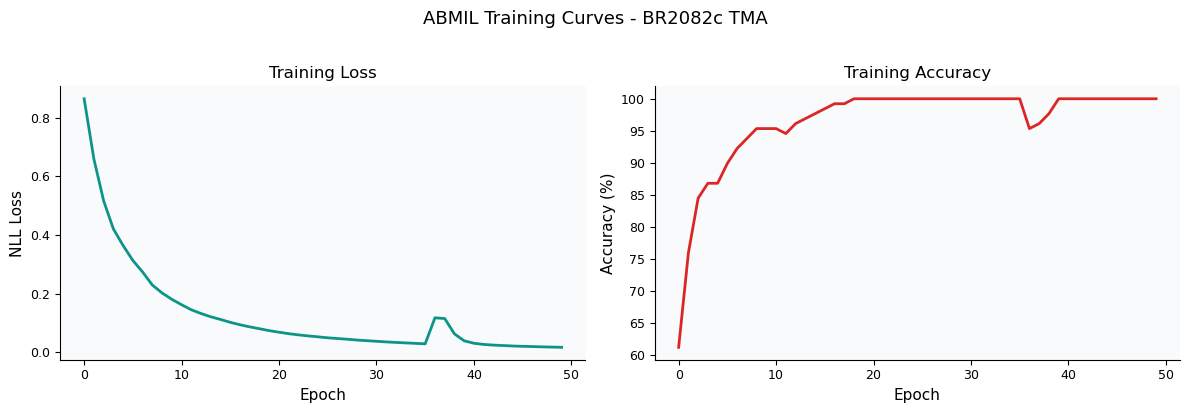

Saved: training_curves.png


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.patch.set_facecolor('white')

axes[0].set_facecolor('#F8FAFC')
axes[0].plot(train_losses, color='#0D9488', linewidth=2)
axes[0].set_xlabel('Epoch', fontname='DejaVu Sans', fontsize=11)
axes[0].set_ylabel('NLL Loss', fontname='DejaVu Sans', fontsize=11)
axes[0].set_title('Training Loss', fontname='DejaVu Sans', fontsize=12)
axes[0].tick_params(labelsize=9)
for spine in ['top', 'right']:
    axes[0].spines[spine].set_visible(False)

axes[1].set_facecolor('#F8FAFC')
axes[1].plot([a * 100 for a in train_accs], color='#DC2626', linewidth=2)
axes[1].set_xlabel('Epoch', fontname='DejaVu Sans', fontsize=11)
axes[1].set_ylabel('Accuracy (%)', fontname='DejaVu Sans', fontsize=11)
axes[1].set_title('Training Accuracy', fontname='DejaVu Sans', fontsize=12)
axes[1].tick_params(labelsize=9)
for spine in ['top', 'right']:
    axes[1].spines[spine].set_visible(False)

plt.suptitle('ABMIL Training Curves - BR2082c TMA',
             fontname='DejaVu Sans', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'training_curves.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved: training_curves.png")

## Cell 12: Evaluate on test set

We run inference on the 33 held-out test cores. For each core we record the predicted class and the attention weights (saved for heatmap visualization later).

We compare directly against Video 3 results in the next cell.

In [13]:
attention_net.eval()
classifier.eval()

all_preds   = []
all_probs   = []
all_attns   = []   # attention weights per core - for heatmaps

with torch.no_grad():
    for bag, label in test_loader:
        bag = bag.squeeze(0).to(device)  # (N_tiles, 1024)
        log_probs, attn = abmil_forward(bag)
        probs = log_probs.exp().cpu().numpy()
        pred  = probs.argmax()
        all_preds.append(pred)
        all_probs.append(probs)
        all_attns.append(attn.cpu().numpy())

all_preds = np.array(all_preds)
test_acc  = (all_preds == test_labels).mean()

print(f"Test accuracy: {test_acc:.1%}")
print()
print(classification_report(test_labels, all_preds,
                             target_names=CLASS_NAMES, zero_division=0))

Test accuracy: 90.9%

               precision    recall  f1-score   support

    Carcinoma       0.90      0.95      0.93        20
         DCIS       0.67      0.50      0.57         4
Normal/Benign       1.00      1.00      1.00         9

     accuracy                           0.91        33
    macro avg       0.86      0.82      0.83        33
 weighted avg       0.90      0.91      0.90        33



## Cell 13: Direct comparison with Video 3

Side-by-side comparison of mean pooling (Video 3) vs attention pooling (Video 4) on the same 33 test cores.

The Video 3 numbers are hardcoded from that notebook's results - same test set, same split.

Metric               Video 3 (Mean Pool)    Video 4 (ABMIL)      Change
----------------------------------------------------------------------
Overall              0.909                  0.909                same (+0.000)
Carcinoma F1         0.950                  0.927                DOWN (-0.023)
DCIS F1              0.570                  0.571                same (+0.001)
Normal F1            0.950                  1.000                UP (+0.050)


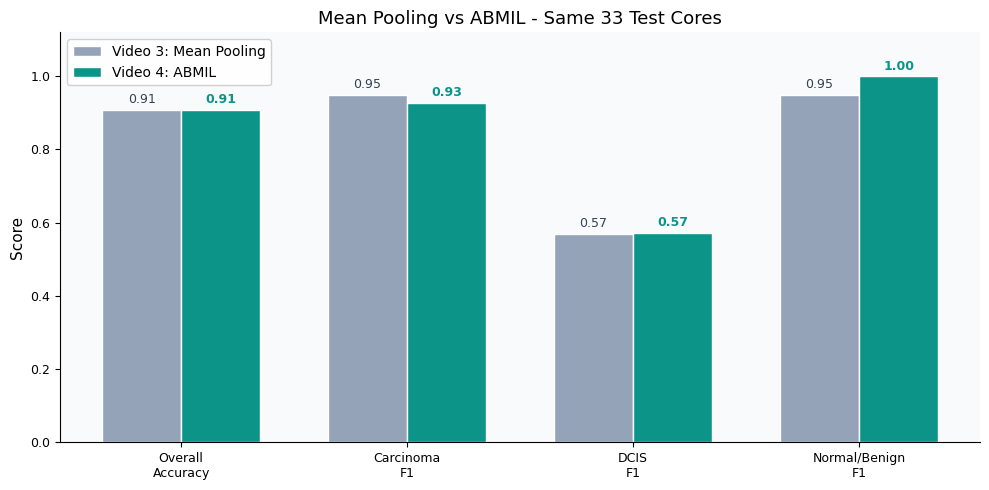

Saved: v3_vs_v4_comparison.png


In [14]:
# Video 3 results (from logistic regression on mean-pooled embeddings)
v3_results = {
    'Overall':       0.909,
    'Carcinoma F1':  0.95,
    'DCIS F1':       0.57,
    'Normal F1':     0.95,
}

from sklearn.metrics import f1_score
v4_f1s = f1_score(test_labels, all_preds, average=None, zero_division=0)

v4_results = {
    'Overall':       test_acc,
    'Carcinoma F1':  v4_f1s[0],
    'DCIS F1':       v4_f1s[1],
    'Normal F1':     v4_f1s[2],
}

print(f"{'Metric':<20} {'Video 3 (Mean Pool)':<22} {'Video 4 (ABMIL)':<20} {'Change'}")
print("-" * 70)
for metric in v3_results:
    v3 = v3_results[metric]
    v4 = v4_results[metric]
    delta = v4 - v3
    arrow = "UP" if delta > 0.01 else ("DOWN" if delta < -0.01 else "same")
    print(f"{metric:<20} {v3:<22.3f} {v4:<20.3f} {arrow} ({delta:+.3f})")

# Bar chart comparison
metrics = ['Overall\nAccuracy', 'Carcinoma\nF1', 'DCIS\nF1', 'Normal/Benign\nF1']
v3_vals = [v3_results[k] for k in v3_results]
v4_vals = [v4_results[k] for k in v4_results]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor('white')
ax.set_facecolor('#F8FAFC')

bars3 = ax.bar(x - width/2, v3_vals, width, label='Video 3: Mean Pooling',
               color='#94A3B8', edgecolor='white')
bars4 = ax.bar(x + width/2, v4_vals, width, label='Video 4: ABMIL',
               color='#0D9488', edgecolor='white')

for bar in bars3:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.2f}', ha='center', va='bottom',
            fontsize=9, fontname='DejaVu Sans', color='#334155')
for bar in bars4:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.2f}', ha='center', va='bottom',
            fontsize=9, fontname='DejaVu Sans', color='#0D9488', fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(metrics, fontname='DejaVu Sans', fontsize=10)
ax.set_ylim(0, 1.12)
ax.set_ylabel('Score', fontname='DejaVu Sans', fontsize=11)
ax.set_title('Mean Pooling vs ABMIL - Same 33 Test Cores',
             fontname='DejaVu Sans', fontsize=13)
ax.legend(fontsize=10, framealpha=0.9)
ax.tick_params(labelsize=9)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'v3_vs_v4_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved: v3_vs_v4_comparison.png")

## Cell 14: Confusion matrix

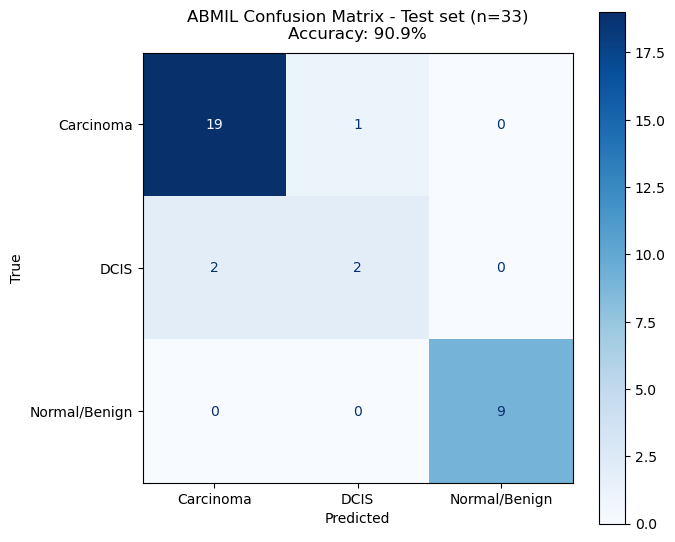

Saved: confusion_matrix_abmil.png


In [15]:
fig, ax = plt.subplots(figsize=(7, 6))
fig.patch.set_facecolor('white')

cm   = confusion_matrix(test_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
disp.plot(ax=ax, colorbar=True, cmap='Blues', values_format='d')

ax.set_title(f'ABMIL Confusion Matrix - Test set (n={len(test_labels)})\n'
             f'Accuracy: {test_acc:.1%}',
             fontname='DejaVu Sans', fontsize=12, pad=10)
ax.set_xlabel('Predicted', fontname='DejaVu Sans', fontsize=10)
ax.set_ylabel('True', fontname='DejaVu Sans', fontsize=10)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'confusion_matrix_abmil.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved: confusion_matrix_abmil.png")

## Cell 15: Attention heatmaps for selected cores

We visualize the attention weights spatially for one representative core per class.

The attention weights from ABMIL are the key output that mean pooling cannot produce. Each non-background tile gets a weight between 0 and 1 (summing to 1 across the bag). High weight = the model is relying on this tile for its prediction. Low weight = this tile is largely ignored.

We also need all tiles including background to reconstruct the full spatial grid, so we re-tile the core at display resolution and place attention weights at the correct grid positions. Background tiles get weight 0.

We pick one correctly classified test core per class - same E14, I6, L5 from Video 3 where possible, for direct visual comparison.

In [16]:
# Find one correctly classified test core per class
demo = {}
for cls_id in range(N_CLASSES):
    for i, (pos, true_lbl, pred_lbl) in enumerate(
            zip(test_positions, test_labels, all_preds)):
        if true_lbl == cls_id and pred_lbl == cls_id:
            demo[cls_id] = (pos, i)
            break
    if cls_id not in demo:
        # Fallback: first test core of this class even if misclassified
        for i, (pos, true_lbl) in enumerate(zip(test_positions, test_labels)):
            if true_lbl == cls_id:
                demo[cls_id] = (pos, i)
                break

print("Demo cores:")
for cls_id, (pos, _) in demo.items():
    print(f"  {CLASS_NAMES[cls_id]}: {pos}")

Demo cores:
  Carcinoma: E14
  DCIS: I6
  Normal/Benign: L5


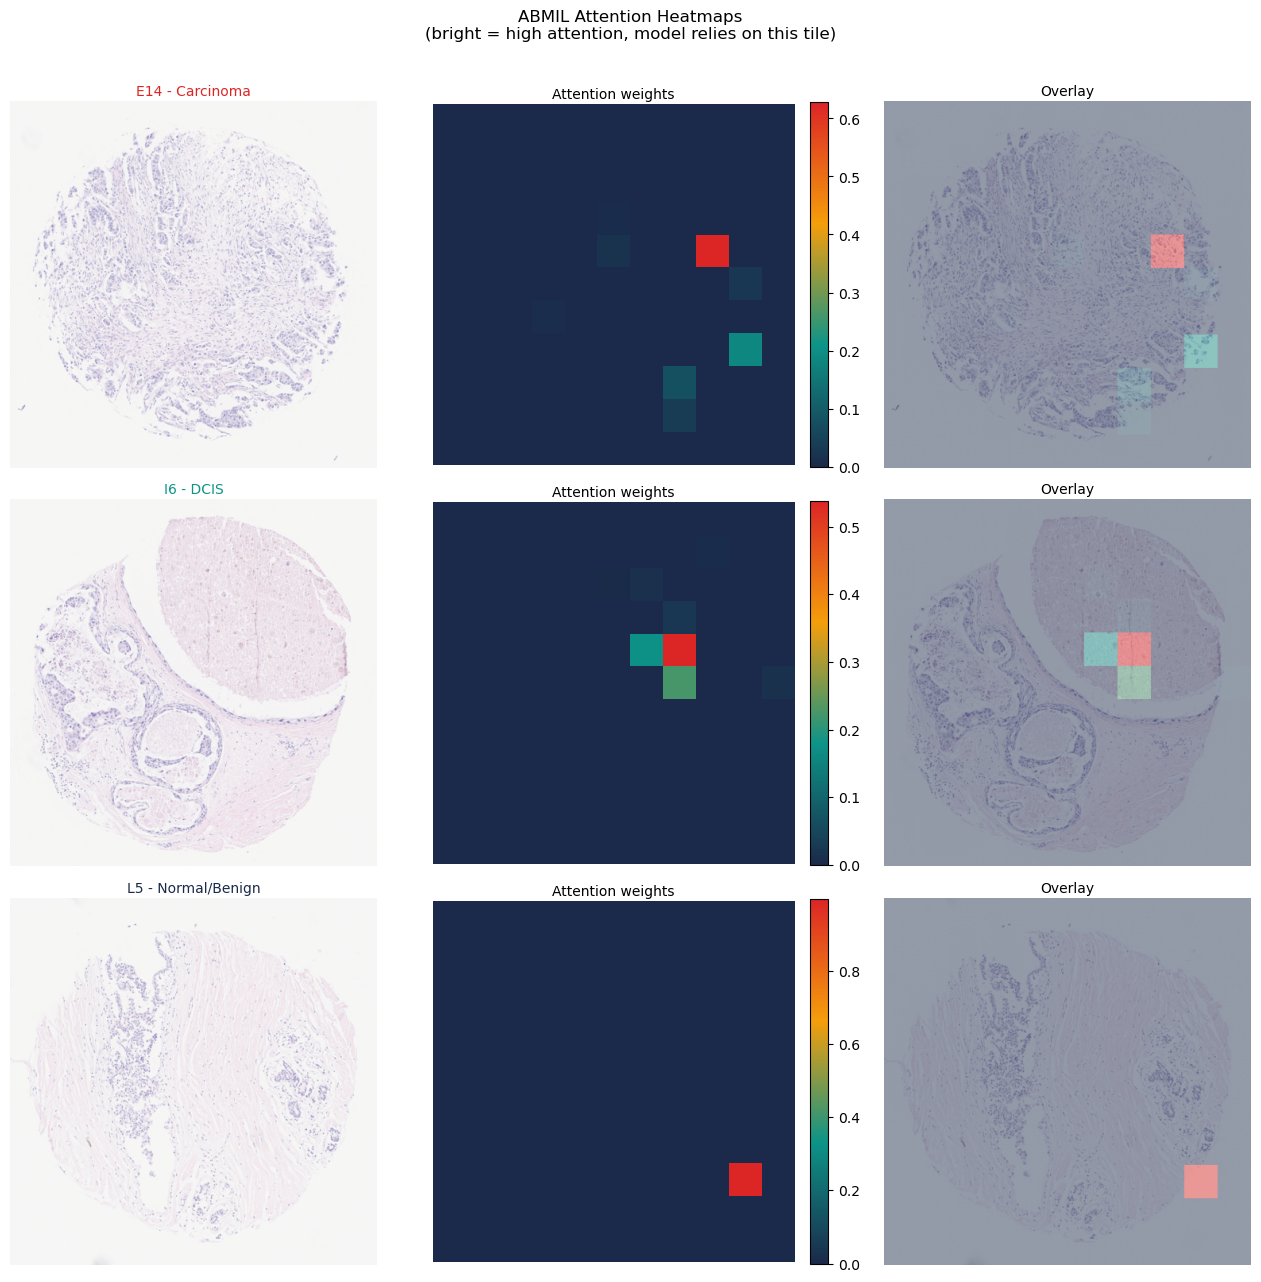

Saved: attention_heatmaps.png


In [17]:
cmap_attn = LinearSegmentedColormap.from_list(
    'attn', ['#1B2A4A', '#0D9488', '#F59E0B', '#DC2626'], N=256)

n_demo = len(demo)
fig, axes = plt.subplots(n_demo, 3, figsize=(13, n_demo * 4.2))
fig.patch.set_facecolor('white')

for row_idx, (cls_id, (pos, test_i)) in enumerate(demo.items()):
    img_path  = df[df['Position'] == pos].iloc[0]['ImagePath']
    img_np    = np.array(Image.open(img_path).convert('RGB'))
    H, W      = img_np.shape[:2]
    n_rows    = (H - TILE_SIZE) // STRIDE + 1
    n_cols    = (W - TILE_SIZE) // STRIDE + 1

    # Get attention weights for this test core
    attn_weights = all_attns[test_i]              # (N_kept_tiles,)
    kept_coords  = test_coords_list[test_i]       # list of (r, c)

    # Build full attention grid (background = 0)
    attn_grid = np.zeros((n_rows, n_cols))
    for k, (r, c) in enumerate(kept_coords):
        ri = r // STRIDE
        ci = c // STRIDE
        if ri < n_rows and ci < n_cols and k < len(attn_weights):
            attn_grid[ri, ci] = attn_weights[k]

    # Display size
    disp_size = n_rows * 42
    img_disp  = np.array(
        Image.fromarray(img_np).resize((disp_size, disp_size)))

    cls_color = CLASS_COLORS[cls_id]

    # Panel 1: original core
    axes[row_idx, 0].imshow(img_disp)
    axes[row_idx, 0].axis('off')
    axes[row_idx, 0].set_title(
        f'{pos} - {CLASS_NAMES[cls_id]}',
        fontsize=10, fontname='DejaVu Sans', color=cls_color, pad=4)

    # Panel 2: attention heatmap
    im = axes[row_idx, 1].imshow(
        attn_grid, cmap=cmap_attn, vmin=0,
        vmax=attn_grid.max() if attn_grid.max() > 0 else 1,
        aspect='equal')
    axes[row_idx, 1].axis('off')
    axes[row_idx, 1].set_title(
        'Attention weights', fontsize=10, fontname='DejaVu Sans', pad=4)
    plt.colorbar(im, ax=axes[row_idx, 1], fraction=0.046, pad=0.04)

    # Panel 3: overlay
    attn_img = np.array(
        Image.fromarray((attn_grid / (attn_grid.max() + 1e-8) * 255).astype(np.uint8))
        .resize((disp_size, disp_size), resample=Image.NEAREST))
    heat_rgb  = (cmap_attn(attn_img / 255.0)[:, :, :3] * 255).astype(np.uint8)
    overlay   = (img_disp.astype(float) * 0.55 +
                 heat_rgb.astype(float) * 0.45).astype(np.uint8)
    axes[row_idx, 2].imshow(overlay)
    axes[row_idx, 2].axis('off')
    axes[row_idx, 2].set_title(
        'Overlay', fontsize=10, fontname='DejaVu Sans', pad=4)

plt.suptitle(
    'ABMIL Attention Heatmaps\n'
    '(bright = high attention, model relies on this tile)',
    fontname='DejaVu Sans', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'attention_heatmaps.png'), dpi=120,
            bbox_inches='tight')
plt.show()
print("Saved: attention_heatmaps.png")

## Cell 16: Top attended tiles per class

For each demo core we display the 6 tiles with the highest attention weights alongside the 6 tiles with the lowest attention weights.

This is the most direct visual explanation of what the attention mechanism has learned. The high-attention tiles should look like the most diagnostically informative tissue for that class. The low-attention tiles should look like stroma, background, or ambiguous tissue.

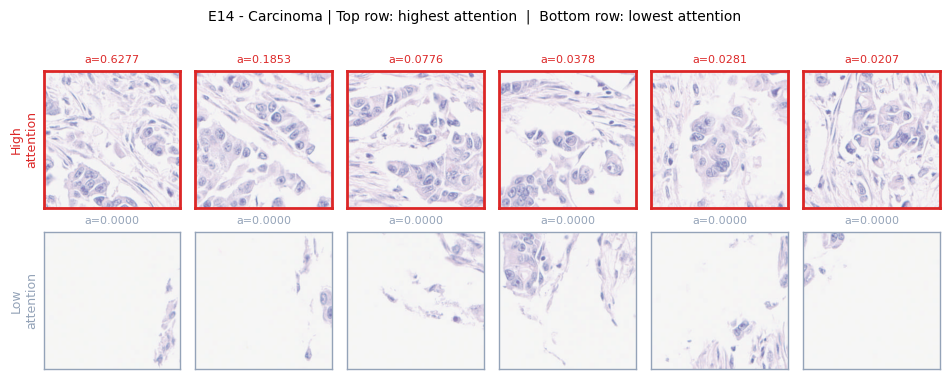

Saved: top_tiles_carcinoma.png


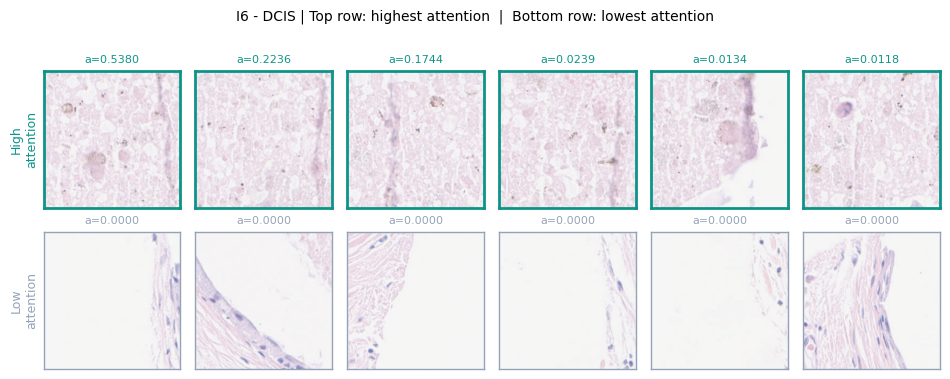

Saved: top_tiles_dcis.png


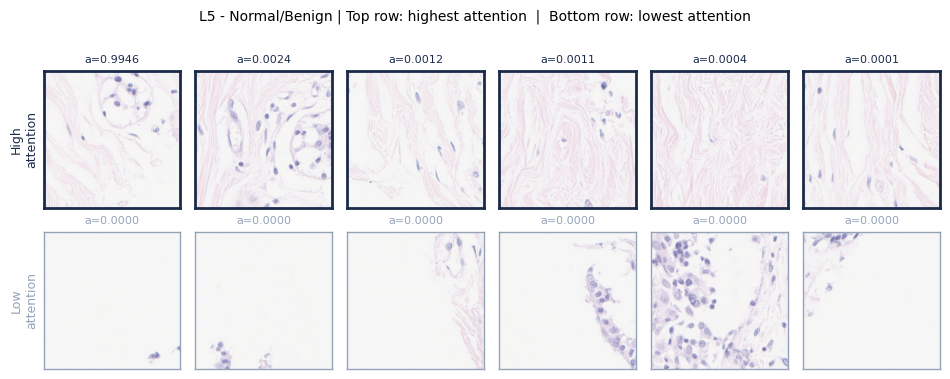

Saved: top_tiles_normal_benign.png


In [18]:
TOP_K = 6

for cls_id, (pos, test_i) in demo.items():
    img_path     = df[df['Position'] == pos].iloc[0]['ImagePath']
    img_np       = np.array(Image.open(img_path).convert('RGB'))
    attn_weights = all_attns[test_i]
    kept_coords  = test_coords_list[test_i]

    # Extract all kept tiles
    kept_tiles = np.array([
        img_np[r:r + TILE_SIZE, c:c + TILE_SIZE]
        for r, c in kept_coords
    ])

    top_idx = np.argsort(attn_weights)[-TOP_K:][::-1]
    bot_idx = np.argsort(attn_weights)[:TOP_K]

    fig, axes = plt.subplots(2, TOP_K, figsize=(TOP_K * 1.6, 3.8))
    fig.patch.set_facecolor('white')
    fig.suptitle(
        f'{pos} - {CLASS_NAMES[cls_id]} | '
        f'Top row: highest attention  |  Bottom row: lowest attention',
        fontname='DejaVu Sans', fontsize=10, y=1.01)

    for k in range(TOP_K):
        # High attention
        ax = axes[0, k]
        ax.imshow(kept_tiles[top_idx[k]])
        ax.set_title(f'a={attn_weights[top_idx[k]]:.4f}',
                     fontsize=8, fontname='DejaVu Sans',
                     color=CLASS_COLORS[cls_id])
        for spine in ax.spines.values():
            spine.set_edgecolor(CLASS_COLORS[cls_id])
            spine.set_linewidth(2)
        ax.set_xticks([]); ax.set_yticks([])

        # Low attention
        ax = axes[1, k]
        ax.imshow(kept_tiles[bot_idx[k]])
        ax.set_title(f'a={attn_weights[bot_idx[k]]:.4f}',
                     fontsize=8, fontname='DejaVu Sans', color='#94A3B8')
        for spine in ax.spines.values():
            spine.set_edgecolor('#94A3B8')
            spine.set_linewidth(1)
        ax.set_xticks([]); ax.set_yticks([])

    axes[0, 0].set_ylabel('High\nattention', fontsize=9,
                           fontname='DejaVu Sans', color=CLASS_COLORS[cls_id])
    axes[1, 0].set_ylabel('Low\nattention', fontsize=9,
                           fontname='DejaVu Sans', color='#94A3B8')

    plt.tight_layout()
    fname = f'top_tiles_{CLASS_NAMES[cls_id].lower().replace("/","_")}.png'
    plt.savefig(os.path.join(OUTPUT_DIR, fname), dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {fname}")

## Cell 17: Attention weight distribution comparison

In Video 3 Cell 15 we showed per-tile probability distributions and noted that I6 DCIS had a flat distribution (mean = 0.63) - evidence that mean pooling was losing signal.

Here we show the attention weight distributions for the same three cores. Unlike probability distributions, attention weights are constrained to sum to 1. What we look for is **concentration**: a few tiles with high weight and most tiles near zero. That concentration means the model has identified which tiles matter.

A uniform attention distribution (all weights ~1/N) would mean the attention mechanism has not learned anything useful and has fallen back to mean pooling. Concentrated attention means the model is focusing on specific regions.

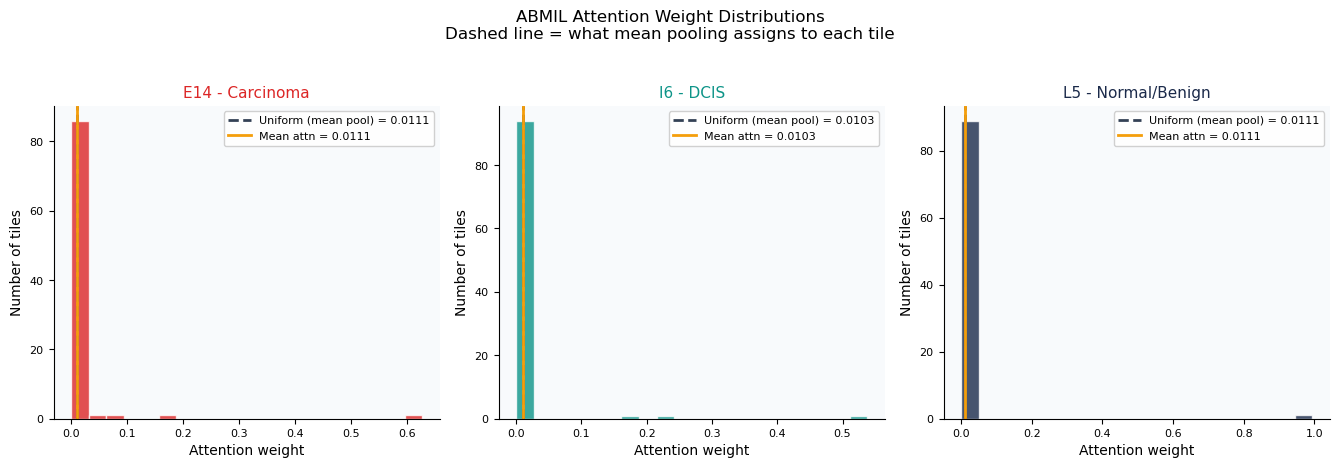

Saved: attention_distributions.png


In [20]:
fig, axes = plt.subplots(1, n_demo, figsize=(4.5 * n_demo, 4.5))
fig.patch.set_facecolor('white')

for ax_idx, (cls_id, (pos, test_i)) in enumerate(demo.items()):
    attn_weights = all_attns[test_i]
    n_tiles      = len(attn_weights)
    uniform_weight = 1.0 / n_tiles  # what mean pooling would assign

    ax = axes[ax_idx]
    ax.set_facecolor('#F8FAFC')
    ax.hist(attn_weights, bins=20, color=CLASS_COLORS[cls_id],
            alpha=0.8, edgecolor='white')
    ax.axvline(uniform_weight, color='#334155', linewidth=2,
               linestyle='--',
               label=f'Uniform (mean pool) = {uniform_weight:.4f}')
    ax.axvline(attn_weights.mean(), color='#F59E0B', linewidth=2,
               linestyle='-',
               label=f'Mean attn = {attn_weights.mean():.4f}')
    ax.set_title(f'{pos} - {CLASS_NAMES[cls_id]}',
                 fontname='DejaVu Sans', fontsize=11,
                 color=CLASS_COLORS[cls_id])
    ax.set_xlabel('Attention weight', fontname='DejaVu Sans', fontsize=10)
    ax.set_ylabel('Number of tiles', fontname='DejaVu Sans', fontsize=10)
    ax.legend(fontsize=8, framealpha=0.9)
    ax.tick_params(labelsize=8)
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)

plt.suptitle(
    'ABMIL Attention Weight Distributions\n'
    'Dashed line = what mean pooling assigns to each tile',
    fontname='DejaVu Sans', fontsize=12, y=1.03)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'attention_distributions.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved: attention_distributions.png")

## Summary

What we built in this notebook:

1. Loaded the same 162 BR2082c TMA cores as Video 3 - fully self-contained, no Video 3 dependencies
2. Extracted per-tile Phikon-v2 embeddings (not mean-pooled) - each core is a bag of (N_tiles, 1024) vectors
3. Defined the ABMIL architecture: attention network learns tile weights, classifier operates on the weighted sum
4. Trained with weighted cross-entropy to handle DCIS class imbalance
5. Evaluated on the same 33 held-out test cores as Video 3 for a fair comparison
6. Visualized attention heatmaps showing spatially concentrated attention on diagnostically relevant regions
7. Showed attention weight distributions - concentrated vs uniform = focused vs mean-pooling behavior

**In Video 5**, we move to a different dataset - the SurGen colorectal cancer WSI collection - and explore spatial analysis of the tumor microenvironment using Phikon-v2 embeddings and neighborhood statistics.

Code and notebooks: github.com/bnsreenu